In [1]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import numpy as np
!python -m pip install plotnine
from plotnine import *
import seaborn as sns
import scipy.stats.stats as stats
!python -m pip install pingouin
import pingouin as pg
from matplotlib.colors import LinearSegmentedColormap

In [31]:
gpt2_df = pd.read_csv(r'data\GPT2-large-dimensions.csv')

In [32]:
gpt2_df.head(3)

,Social.Category,Source,gender.main,gender_norm.main,gender.ext,gender_norm.ext,gender.red,gender_norm.red,age.main,age_norm.main,age.ext,age_norm.ext,age.red,age_norm.red
0,abandoned infant,GPT2,-0.197087,0.540877,0.001662,0.527162,-0.108243,0.561858,-0.070237,0.357426,-0.004732,0.319985,-0.055446,0.419423
1,abandoned person,GPT2,-0.199134,0.535577,0.001236,0.523567,-0.110507,0.554830,-0.065570,0.382294,-0.001178,0.343708,-0.048989,0.477159
2,abiogenist,GPT2,-0.231156,0.452671,0.004317,0.549545,-0.151075,0.428889,-0.097012,0.214761,-0.026444,0.175097,-0.063784,0.344863


In [33]:
gpt2_df.drop(columns='Source', inplace=True)

In [34]:
columns = ['social_category', 'gender_main', 'gender_norm_main', 'gender_ext', 'gender_norm_ext', 
            'gender_red', 'gender_norm_red', 'age_main', 'age_norm_main', 'age_ext', 
            'age_norm_ext', 'age_red', 'age_norm_red']

gpt2_df.columns = columns

## Correlation Between Age and Gender

In [36]:
pg.corr(gpt2_df['gender_norm_main'], gpt2_df['age_norm_main'])

,n,r,CI95,p_val,BF10,power
pearson,3495,0.872559,"[0.86, 0.88]",0.0,inf,1.0


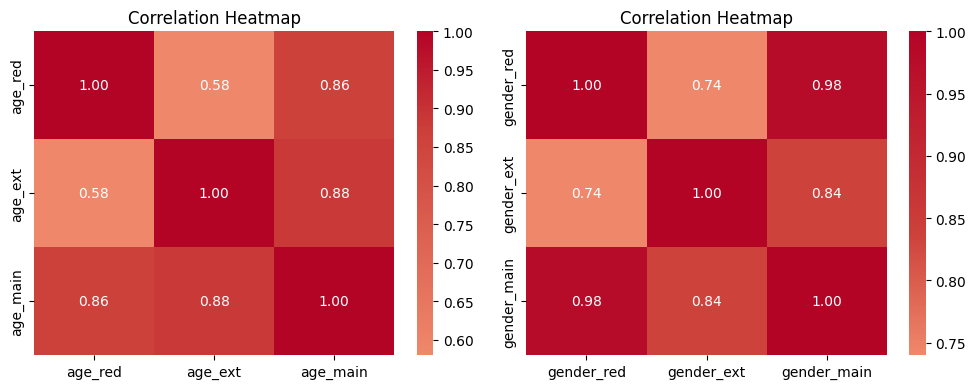

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
heatmap_age_data = gpt2_df[['age_red', 'age_ext', 'age_main']].corr()
colors = [(0, '#ef886b'), (0.69, '#cc403a'), (1.00, '#b40426')]
cmap_age = LinearSegmentedColormap.from_list('my_cmap', colors)
sns.heatmap(heatmap_age_data, annot=True, fmt='.2f', cmap=cmap_age, vmin=0.58, ax=axes[0])
axes[0].set_title('Correlation Heatmap')

heatmap_gender_data = gpt2_df[['gender_red', 'gender_ext', 'gender_main']].corr()
colors = [(0, '#ef886b'), (0.38, '#cc403a'), (1.00, '#b40426')]
cmap_gender = LinearSegmentedColormap.from_list('my_cmap', colors)
sns.heatmap(heatmap_gender_data, annot=True, fmt='.2f', cmap=cmap_gender, vmin=0.74, ax=axes[1])
axes[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

## Relationship between Age and Gender

In [40]:
gpt2_df.head(3)

,social_category,gender_main,gender_norm_main,gender_ext,gender_norm_ext,gender_red,gender_norm_red,age_main,age_norm_main,age_ext,age_norm_ext,age_red,age_norm_red
0,abandoned infant,-0.197087,0.540877,0.001662,0.527162,-0.108243,0.561858,-0.070237,0.357426,-0.004732,0.319985,-0.055446,0.419423
1,abandoned person,-0.199134,0.535577,0.001236,0.523567,-0.110507,0.554830,-0.065570,0.382294,-0.001178,0.343708,-0.048989,0.477159
2,abiogenist,-0.231156,0.452671,0.004317,0.549545,-0.151075,0.428889,-0.097012,0.214761,-0.026444,0.175097,-0.063784,0.344863


In [41]:
age_gender_mod = smf.ols("age_norm_main ~ gender_norm_main", data=gpt2_df)
age_gender_res = age_gender_mod.fit()
age_gender_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          age_norm_main   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                 1.114e+04
Date:                Fri, 03 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:43:39   Log-Likelihood:                 5425.6
No. Observations:                3495   AIC:                        -1.085e+04
Df Residuals:                    3493   BIC:                        -1.083e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -0.0211      0.003     -6.510      0.000      -0.027      -0.015
gender_norm_main     0.7450      0.007    105.565      0.000       0.731       0.759
==============================================================================
Omnibus:                      829.901   Durbin-Watson:                   1.255
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4643.267
Skew:                           1.012   Prob(JB):                         0.00
Kurtosis:                       8.271   Cond. No.                         9.75
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""